In [ ]:
import pandas as pd
import numpy as np
import japanize_matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# データ
x = [3.36, 2.88, 3.63, 3.41, 3.78, 4.02, 4.00, 4.23, 3.73,
     3.85, 3.97, 4.51, 4.54, 5.00, 5.00, 4.72, 5.00]

y = [65, 156, 100, 134, 16, 108, 121, 4, 39,
     143, 56, 26, 22, 1, 1, 5, 65]

# DataFrame 作成
df = pd.DataFrame({
    "x": x,
    "y": y
})

In [3]:
df

,x,y
0,3.36,65
1,2.88,156
2,3.63,100
3,3.41,134
4,3.78,16
5,4.02,108
6,4.00,121
7,4.23,4
8,3.73,39
9,3.85,143


## (a)

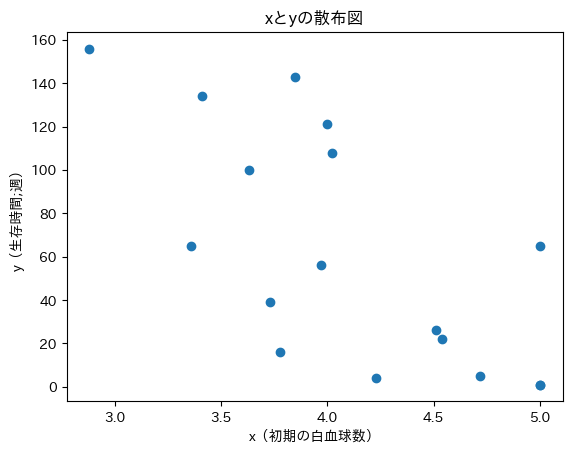

In [4]:
plt.title("xとyの散布図")
plt.scatter(df["x"], df["y"])
plt.xlabel("x（初期の白血球数）")
plt.ylabel("y（生存時間;週）")
plt.savefig("4_2_a.png")
plt.show()

## (c)

In [ ]:
model_exp = smf.glm(
    formula="y ~ x",
    data=df,
    family=sm.families.Gamma(link=sm.families.links.log())
)
results_exp = model_exp.fit()

In [6]:
results_exp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                   17
Model:                            GLM   Df Residuals:                       15
Model Family:                   Gamma   Df Model:                            1
Link Function:                    log   Scale:                         0.93886
Method:                          IRLS   Log-Likelihood:                -83.894
Date:                Wed, 17 Jun 2026   Deviance:                       19.457
Time:                        00:45:49   Pearson chi2:                     14.1
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3480
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.4775      1.603      5.287      0.000       5.335      11.620
x             -1.1093      0.387     -2.865      0.004      -1.868      -0.350
==============================================================================
"""

## (d)

In [7]:
df["pred"] = np.exp(results_exp.params["x"] * df["x"] + results_exp.params["Intercept"])
df["std_resid"] = (df["y"] - df["pred"]) / df["pred"]

In [8]:
df

,x,y,pred,std_resid
0,3.36,65,115.613954,-0.437784
1,2.88,156,196.904661,-0.207738
2,3.63,100,85.690865,0.166986
3,3.41,134,109.376030,0.225131
4,3.78,16,72.555482,-0.779479
5,4.02,108,55.596488,0.942569
6,4.00,121,56.843734,1.128643
7,4.23,4,44.043046,-0.909180
8,3.73,39,76.693459,-0.491482
9,3.85,143,67.134675,1.130047


/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_30660/3263341955.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = np.exp(results_exp.params[0] + results_exp.params[1] * x_range)


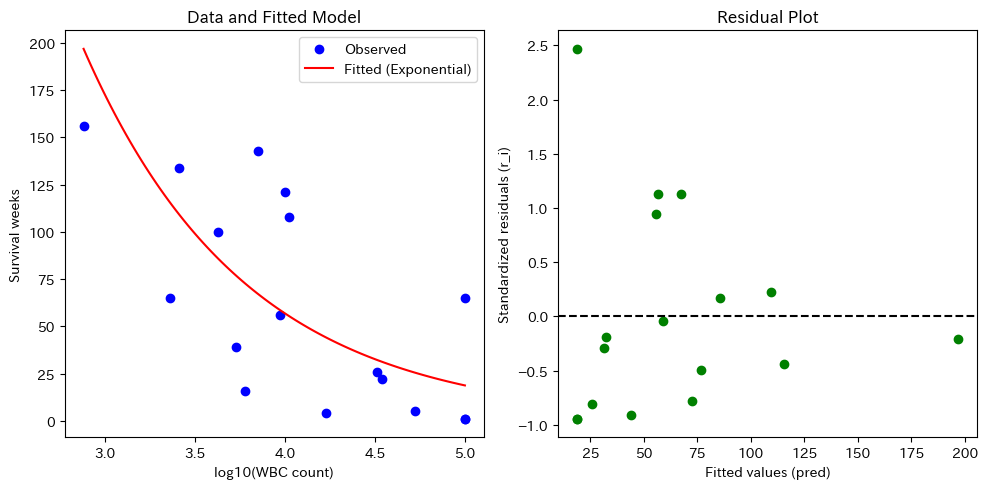

In [9]:
# 5. 可視化
plt.figure(figsize=(10, 5))

# プロット1: データと適合曲線
plt.subplot(1, 2, 1)
plt.scatter(df['x'], df['y'], color='blue', label='Observed')
x_range = np.linspace(df['x'].min(), df['x'].max(), 100)
y_pred = np.exp(results_exp.params[0] + results_exp.params[1] * x_range)
plt.plot(x_range, y_pred, color='red', label='Fitted (Exponential)')
plt.xlabel('log10(WBC count)')
plt.ylabel('Survival weeks')
plt.title('Data and Fitted Model')
plt.legend()

# プロット2: 標準化残差の確認
plt.subplot(1, 2, 2)
plt.scatter(df['pred'], df['std_resid'], color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Fitted values (pred)')
plt.ylabel('Standardized residuals (r_i)')
plt.title('Residual Plot')

plt.tight_layout()
plt.savefig("4_2_d.png")
plt.show()